In [15]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split

distance of the points are calculated using :  
* euclidean distance : √(($a_{2}$ - $a_{1}$)$^{2}$ * ($b_{2}$ - $b_{1}$)$^{2}$)  
for multiple coordinates,  
√( ∑ ($b_{i}$ - $a_{i}$)$^{2}$)  
  
  
$K$ is the number of neighbours we consider so, there is no specific number for choosing the value.  
smaller $K$ may cause overfitting.   
Larger $K$ may cause underfitting.  

In [6]:
data=pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\Machine Learning\0.Data\binomial_logistic_regression_dataset.csv')
data.head()

,Hours_Studied,Attendance_Percentage,Pass(1)_Fail(0)
0,5.993428,66.710050,1
1,4.723471,69.398190,1
2,6.295377,82.472936,1
3,8.046060,81.103703,1
4,4.531693,74.790984,1


In [7]:
data.rename(columns={'Pass(1)_Fail(0)':'Pass'},inplace=True)

In [12]:
x=data.drop(columns='Pass').values
y=data['Pass'].values

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

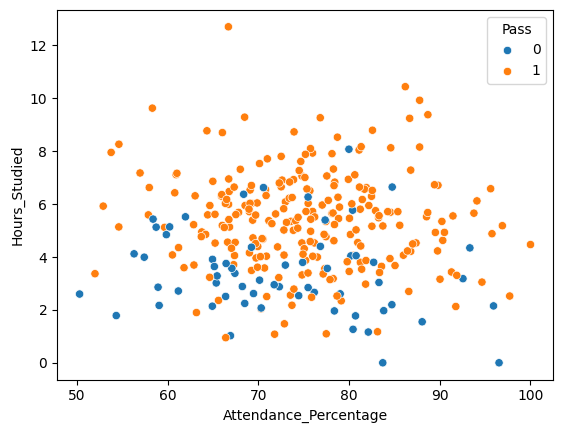

In [16]:
sns.scatterplot(x=data['Attendance_Percentage'],y=data['Hours_Studied'],hue=data['Pass'])
plt.show()

In [17]:
def euclid(a,b):
    return np.sqrt(np.sum((b-a)**2))

In [61]:
class KNN:
    def __init__(self,k):
        self.k=k
    
    def fit(self,x,y):
        self.x_train=x
        self.y_train=y
    
    def predict(self,new_data):
        predictions=[self.predict_class(new_point) for new_point in new_data]
        return predictions
    
    def predict_class(self,new_point):
        distances=[euclid(point,new_point) for point in self.x_train]

        near=np.argsort(distances)[:self.k]
        nearest_label=[self.y_train[i] for i in near]

        common_val=Counter(nearest_label).most_common(1)[0][0]

        return common_val

In [62]:
model=KNN(5)

In [63]:
model.fit(x_train,y_train)

In [64]:
predictions=model.predict(x_test)

In [65]:
accuracy=np.mean(predictions == y_test)
accuracy*100

81.33333333333333

In [66]:
point=np.array([5.993428,66.710050])
model.predict_class(point) # correct prediction

1

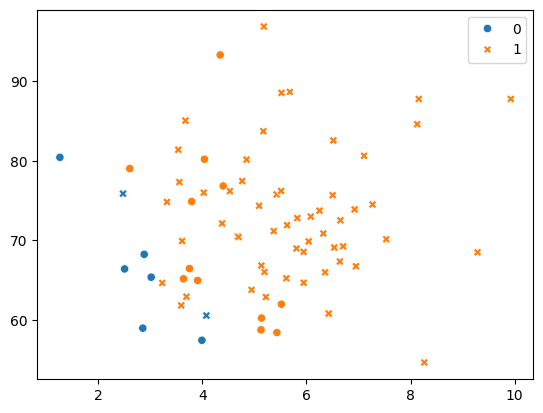

In [68]:
sns.scatterplot(x=x_test[:,0],y=x_test[:,1],hue=predictions,style=y_test)
plt.show()